# Restaurant Revenue Prediction — Analyse Exploratoire

**Objectif :** Explorer et comprendre les données pour guider la modélisation.

**Dataset :** TFI Restaurant Revenue Prediction (Kaggle)

## 0. Imports & chargement des données

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from restaurant_revenue.data.load import load_data

train, test = load_data()
print(f"Train : {train.shape} | Test : {test.shape}")

Train : (137, 43) | Test : (100000, 42)


## 1. Aperçu général

In [2]:
print("=== TYPES ===")
print(train.dtypes)
print("\n=== APERÇU ===")
train.head()

=== TYPES ===
Id              int64
Open Date      object
City           object
City Group     object
Type           object
P1              int64
P2            float64
P3            float64
P4            float64
P5              int64
P6              int64
P7              int64
P8              int64
P9              int64
P10             int64
P11             int64
P12             int64
P13           float64
P14             int64
P15             int64
P16             int64
P17             int64
P18             int64
P19             int64
P20             int64
P21             int64
P22             int64
P23             int64
P24             int64
P25             int64
P26           float64
P27           float64
P28           float64
P29           float64
P30             int64
P31             int64
P32             int64
P33             int64
P34             int64
P35             int64
P36             int64
P37             int64
revenue       float64
dtype: object

=== APERÇU ===


,Id,Open Date,City,City Group,Type,P1,P2,P3,P4,P5,...,P29,P30,P31,P32,P33,P34,P35,P36,P37,revenue
0,0,07/17/1999,İstanbul,Big Cities,IL,4,5.0,4.0,4.0,2,...,3.0,5,3,4,5,5,4,3,4,5653753.0
1,1,02/14/2008,Ankara,Big Cities,FC,4,5.0,4.0,4.0,1,...,3.0,0,0,0,0,0,0,0,0,6923131.0
2,2,03/09/2013,Diyarbakır,Other,IL,2,4.0,2.0,5.0,2,...,3.0,0,0,0,0,0,0,0,0,2055379.0
3,3,02/02/2012,Tokat,Other,IL,6,4.5,6.0,6.0,4,...,7.5,25,12,10,6,18,12,12,6,2675511.0
4,4,05/09/2009,Gaziantep,Other,IL,3,4.0,3.0,4.0,2,...,3.0,5,1,3,2,3,4,3,3,4316715.0


### Observations — Structure du dataset

- **137 observations** dans le train, **100 000** dans le test : le jeu d'entraînement est **extrêmement petit**. Ce déséquilibre est un enjeu majeur du projet (risque de sur-apprentissage, validation délicate).
- **43 colonnes** : 1 cible (`revenue`), 4 catégorielles (`Open Date`, `City`, `City Group`, `Type`), 37 features numériques obfusquées (`P1`–`P37`), 1 identifiant (`Id`).
- Les features `P1`–`P37` sont anonymisées — on ne connaît pas leur sémantique, mais certaines sont des entiers (scores ?) et d'autres des flottants (ratios ?).
- `Open Date` est un `object` : il faudra la parser et en extraire une feature temporelle (ancienneté du restaurant).
- `Id` ne porte aucune information prédictive : à exclure de la modélisation.

### 1.2 Valeurs manquantes

In [3]:
def missing_report(df, name):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    if miss.empty:
        print(f"{name} : aucune valeur manquante ✓")
    else:
        pct = (miss / len(df) * 100).round(2)
        print(f"{name} — {len(miss)} colonnes avec des NaN :\n")
        print(pd.DataFrame({"count": miss, "pct (%)": pct}).to_string())

missing_report(train, "Train")
print()
missing_report(test, "Test")

Train : aucune valeur manquante ✓

Test : aucune valeur manquante ✓


### 1.3 Doublons

In [4]:
n_dup_train = train.duplicated().sum()
n_dup_test  = test.duplicated().sum()
print(f"Doublons train : {n_dup_train}")
print(f"Doublons test  : {n_dup_test}")

Doublons train : 0
Doublons test  : 0


### 1.4 Statistiques descriptives

In [5]:
train.describe(include="all").T.style.format(precision=2)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,137.00,nan,nan,nan,68.00,39.69,0.00,34.00,68.00,102.00,136.00
Open Date,137,134,02/23/2010,2,nan,nan,nan,nan,nan,nan,nan
City,137,34,İstanbul,50,nan,nan,nan,nan,nan,nan,nan
City Group,137,2,Big Cities,78,nan,nan,nan,nan,nan,nan,nan
Type,137,3,FC,76,nan,nan,nan,nan,nan,nan,nan
P1,137.00,nan,nan,nan,4.01,2.91,1.00,2.00,3.00,4.00,12.00
P2,137.00,nan,nan,nan,4.41,1.51,1.00,4.00,5.00,5.00,7.50
P3,137.00,nan,nan,nan,4.32,1.03,0.00,4.00,4.00,5.00,7.50
P4,137.00,nan,nan,nan,4.37,1.02,3.00,4.00,4.00,5.00,7.50
P5,137.00,nan,nan,nan,2.01,1.21,1.00,1.00,2.00,2.00,8.00


### Synthèse — Section 1

| Aspect | Observation | Question ouverte |
|---|---|---|
| Taille train | **137 lignes** seulement | Quel impact sur la validation ? → à traiter en modélisation |
| Taille test | **100 000 lignes** | On prédit sur ~730× plus de données qu'on en a pour entraîner |
| Valeurs manquantes | Aucune dans train ni test | Pas d'imputation nécessaire ✓ |
| Doublons | Aucun | Dataset propre ✓ |
| Features P1–P37 | Anonymisées, mix int/float | Quelle est leur distribution ? Sont-elles corrélées avec revenue ? → Section 4 & 5 |
| `Open Date` | Chaîne texte `MM/DD/YYYY` | Comment en extraire une information utile ? → Section 7 |
| `Id` | Identifiant séquentiel | À supprimer avant modélisation |
| `City` | **34 villes distinctes** | Est-ce trop de modalités pour un encodage direct ? → Section 3 |
| `revenue` | Float continu, forte amplitude | Quelle est la distribution ? Y a-t-il des outliers ? → Section 2 & 6 |

## 2. Variable cible — `revenue`

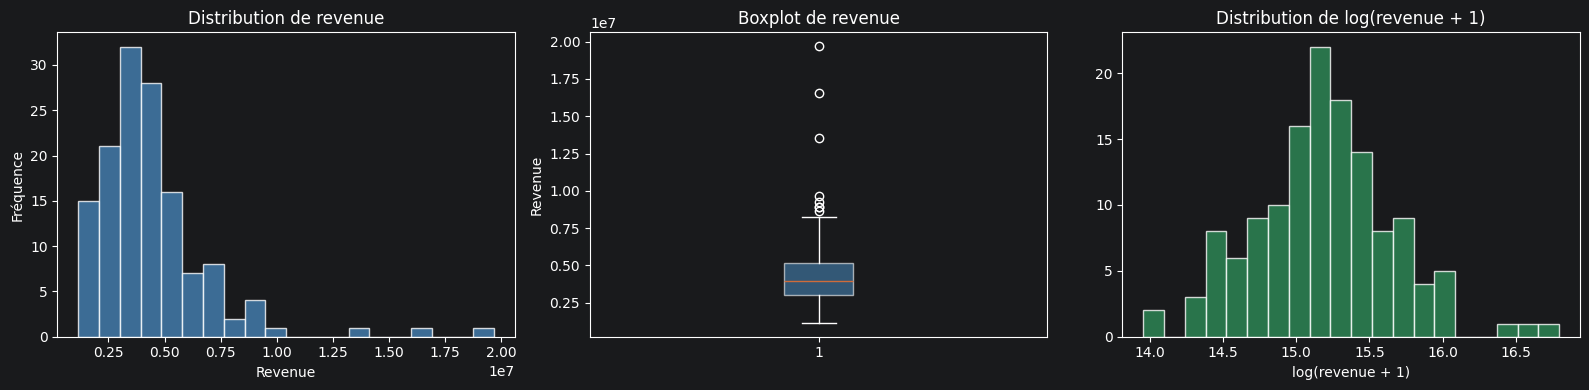

Skewness         : 2.793
Skewness (log)   : 0.307
Min              :       1,149,870
Médiane          :       3,939,804
Moyenne          :       4,453,533
Max              :      19,696,939


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train['revenue'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution de revenue')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Fréquence')

axes[1].boxplot(train['revenue'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de revenue')
axes[1].set_ylabel('Revenue')

log_rev = np.log1p(train['revenue'])
axes[2].hist(log_rev, bins=20, color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribution de log(revenue + 1)')
axes[2].set_xlabel('log(revenue + 1)')

plt.tight_layout()
plt.show()

print(f"Skewness         : {train['revenue'].skew():.3f}")
print(f"Skewness (log)   : {log_rev.skew():.3f}")
print(f"Min              : {train['revenue'].min():>15,.0f}")
print(f"Médiane          : {train['revenue'].median():>15,.0f}")
print(f"Moyenne          : {train['revenue'].mean():>15,.0f}")
print(f"Max              : {train['revenue'].max():>15,.0f}")

### Observations — Distribution de `revenue`

#### Chiffres réels
| Statistique | Valeur |
|-------------|--------|
| Minimum | 1 149 870 |
| Médiane | 3 939 804 |
| Moyenne | 4 453 533 |
| Maximum | 19 696 939 |
| Skewness brut | **2.793** |
| Skewness après log | **0.307** |

#### Ce que ça signifie concrètement
- La **moyenne (4.45M) dépasse nettement la médiane (3.94M)** : quelques restaurants à très fort revenu (visibles dans la longue queue à droite de l'histogramme) tirent la distribution vers le haut.
- Le restaurant le plus rentable gagne **17× plus** que le moins rentable — une amplitude massive pour seulement 137 observations.
- La skewness de **2.793** est très élevée (on considère une distribution fortement asymétrique au-delà de 1).

#### Impact de la transformation logarithmique
- La log-transformation ramène la skewness de **2.793 → 0.307** : divisée par presque 10.
- Concrètement : un modèle entraîné sur `log(revenue)` fait des erreurs beaucoup plus homogènes sur toute la plage de valeurs, sans être dominé par les quelques valeurs extrêmes.
- **Décision** : entraîner sur `log1p(revenue)`, prédire avec `expm1()` en sortie. L'identité de ces restaurants extrêmes sera révélée en Section 6 (Outliers).

### 2.2 Revenue par segment — City Group & Type

Les graphiques ci-dessus montrent la distribution globale de `revenue`. Mais est-ce que tous les restaurants ont la même distribution ? Ou est-ce que le City Group et le Type influencent fortement le niveau de revenu ?

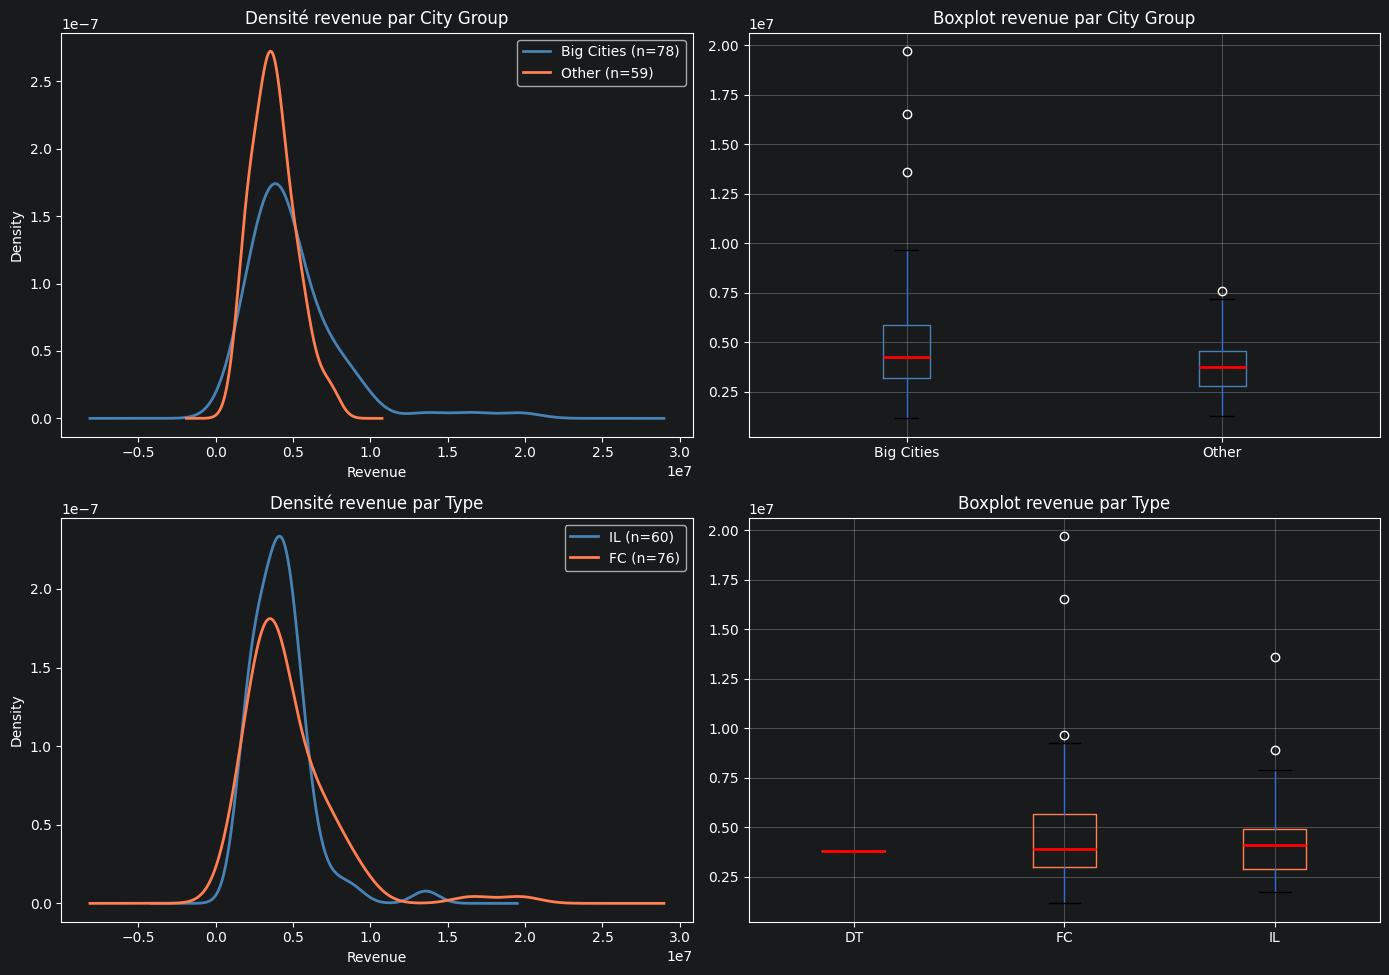

In [20]:
palette_cg = {'Big Cities': 'steelblue', 'Other': 'coral'}
palette_tp = {'IL': 'steelblue', 'FC': 'coral', 'DT': 'seagreen'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KDE revenue par City Group
for group, color in palette_cg.items():
    subset = train[train['City Group'] == group]['revenue']
    subset.plot.kde(ax=axes[0, 0], label=f'{group} (n={len(subset)})', color=color, linewidth=2)
axes[0, 0].set_title('Densité revenue par City Group')
axes[0, 0].set_xlabel('Revenue')
axes[0, 0].legend()

# Boxplot revenue par City Group
train.boxplot(column='revenue', by='City Group', ax=axes[0, 1],
              boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Boxplot revenue par City Group')
axes[0, 1].set_xlabel('')
plt.sca(axes[0, 1])
plt.title('Boxplot revenue par City Group')

# KDE revenue par Type
for typ, color in palette_tp.items():
    subset = train[train['Type'] == typ]['revenue']
    if len(subset) > 2:
        subset.plot.kde(ax=axes[1, 0], label=f'{typ} (n={len(subset)})', color=color, linewidth=2)
axes[1, 0].set_title('Densité revenue par Type')
axes[1, 0].set_xlabel('Revenue')
axes[1, 0].legend()

# Boxplot revenue par Type
train.boxplot(column='revenue', by='Type', ax=axes[1, 1],
              boxprops=dict(color='coral'), medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Boxplot revenue par Type')
axes[1, 1].set_xlabel('')
plt.sca(axes[1, 1])
plt.title('Boxplot revenue par Type')

plt.suptitle('')
plt.tight_layout()
plt.show()

### Observations — Revenue par segment

#### City Group : une différence de profil, pas juste de moyenne
- **Big Cities** : distribution étalée avec une longue queue vers la droite — les valeurs extrêmes au-delà de 10–15M se trouvent toutes dans ce groupe. La KDE montre un pic vers 3–4M mais avec une traîne importante.
- **Other** : distribution beaucoup plus resserrée autour de 2–4M, sans les valeurs extrêmes. L'écart-type de "Other" (1.4M) est **2× plus petit** que celui de Big Cities (3.1M).
- **Conclusion** : `City Group` ne capture pas seulement une différence de moyenne (+13%), mais une différence de **variance** fondamentale. Big Cities = potentiel plus élevé, mais résultats bien plus variables. "Other" = plus prévisible, mais plafonné.

#### Type : FC et IL quasi-identiques, DT inexploitable
- Les courbes KDE de FC et IL se superposent presque entièrement. Les médianes sont très proches (FC : 3.87M, IL : 4.08M) — la différence est trop faible pour être statistiquement significative sur 60–76 restaurants.
- **DT (Drive-Through) : 1 seul restaurant dans le train.** Sa courbe n'apparaît pas dans la KDE (impossible de calculer une densité sur 1 point) et son boxplot se réduit à une ligne unique. Aucune conclusion possible sur ce type.
- **Implication** : `Type` sera encodé en one-hot par précaution, mais son pouvoir prédictif sera probablement faible — à confirmer via l'importance des features après entraînement.

## 3. Variables catégorielles

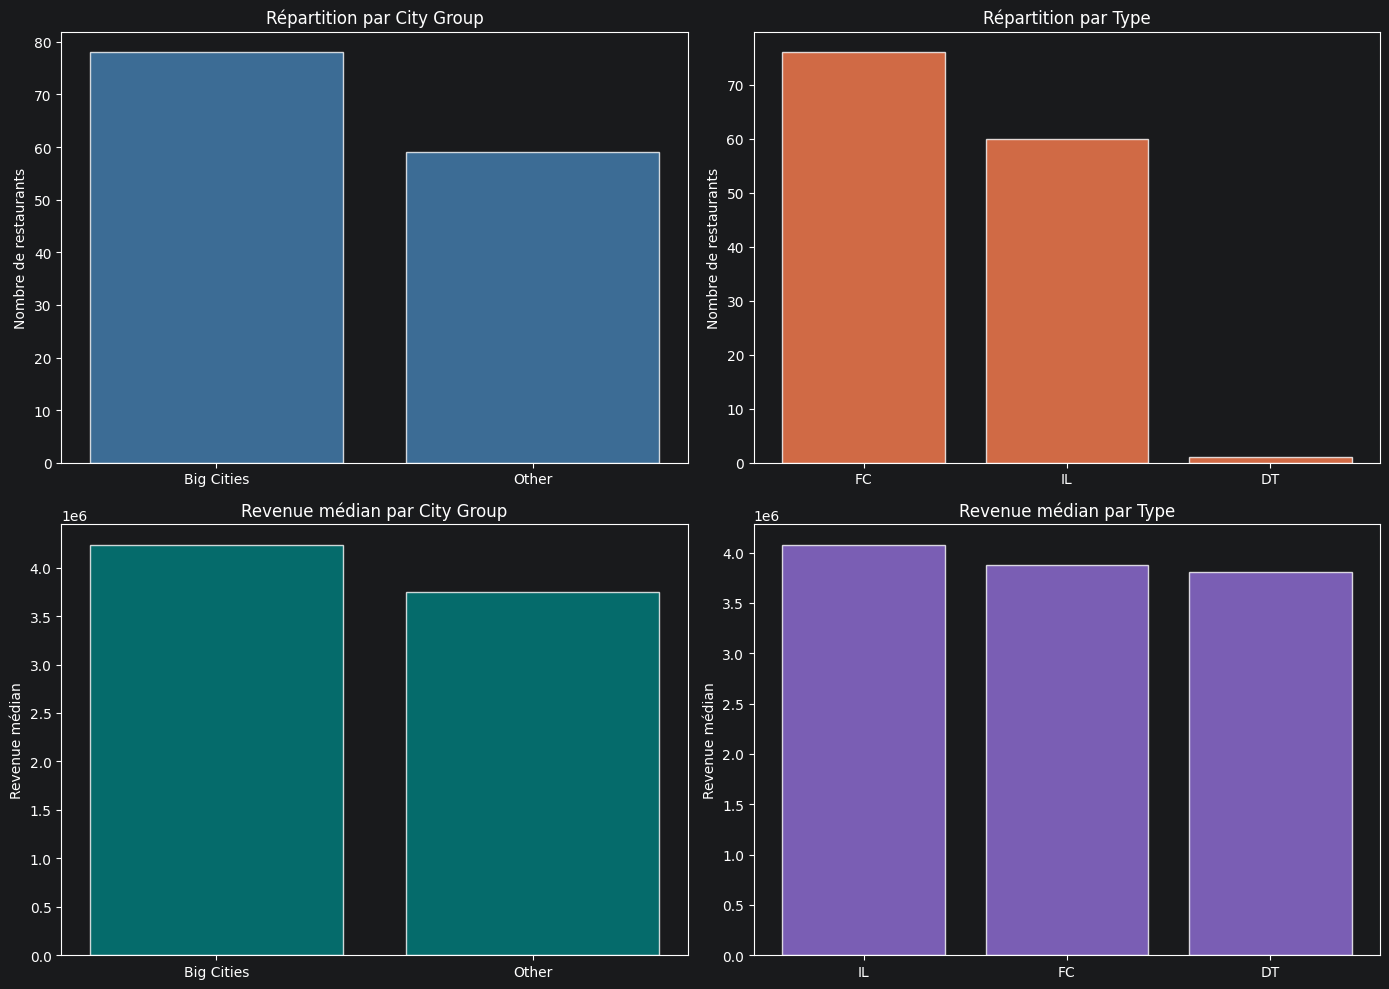

Revenue stats par City Group :
            count     median       mean        std
City Group                                        
Big Cities     78  4234908.0  4983480.0  3094033.0
Other          59  3745135.0  3752924.0  1405195.0

Revenue stats par Type :
      count     median       mean        std
Type                                        
DT        1  3810007.0  3810007.0        NaN
FC       76  3873650.0  4683963.0  2997701.0
IL       60  4076087.0  4172379.0  1928192.0

Nombre de villes distinctes : 34


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cg = train['City Group'].value_counts()
axes[0, 0].bar(cg.index, cg.values, color='steelblue', alpha=0.8, edgecolor='white')
axes[0, 0].set_title('Répartition par City Group')
axes[0, 0].set_ylabel('Nombre de restaurants')

tp = train['Type'].value_counts()
axes[0, 1].bar(tp.index, tp.values, color='coral', alpha=0.8, edgecolor='white')
axes[0, 1].set_title('Répartition par Type')
axes[0, 1].set_ylabel('Nombre de restaurants')

rev_cg = train.groupby('City Group')['revenue'].median().sort_values(ascending=False)
axes[1, 0].bar(rev_cg.index, rev_cg.values, color='teal', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Revenue médian par City Group')
axes[1, 0].set_ylabel('Revenue médian')

rev_tp = train.groupby('Type')['revenue'].median().sort_values(ascending=False)
axes[1, 1].bar(rev_tp.index, rev_tp.values, color='mediumpurple', alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Revenue médian par Type')
axes[1, 1].set_ylabel('Revenue médian')

plt.tight_layout()
plt.show()

print("Revenue stats par City Group :")
print(train.groupby('City Group')['revenue'].agg(['count', 'median', 'mean', 'std']).round(0))
print("\nRevenue stats par Type :")
print(train.groupby('Type')['revenue'].agg(['count', 'median', 'mean', 'std']).round(0))
print(f"\nNombre de villes distinctes : {train['City'].nunique()}")

### Observations — Variables catégorielles

#### City Group : différence de revenu réelle
| City Group | n | Médiane | Moyenne | Std |
|---|---|---|---|---|
| Big Cities | 78 | **4 234 908** | 4 983 480 | 3 094 033 |
| Other | 59 | **3 745 135** | 3 752 924 | 1 405 205 |

- Les Big Cities ont un revenu médian **13% plus élevé** que les "Other", mais surtout un écart-type **2× plus grand** : les Big Cities concentrent à la fois les restaurants les plus rentables ET les plus variables. "Other" est plus homogène.
- Cette variable sera une feature clé — à encoder en one-hot (1 colonne).

#### Type : déséquilibre extrême
| Type | n | Médiane |
|---|---|---|
| FC (Food Court) | 76 | 3 873 650 |
| IL (Inline) | 60 | 4 076 087 |
| DT (Drive-Through) | **1** | 3 810 007 |

- **Attention** : le type DT n'a qu'**un seul restaurant** dans le train ! Il est impossible d'en tirer des conclusions statistiques et ce type ne contribuera quasiment pas au modèle.
- IL a un revenu médian légèrement supérieur à FC, mais la différence est faible.
- **Risque** : lors de la validation croisée avec 5 folds, DT ne sera représenté que dans 1 fold → résultats instables.

#### City : 34 villes distinctes
- 34 villes pour 137 observations. Un one-hot créerait 34 colonnes pour 137 lignes → trop de paramètres.
- **Décision** : utiliser `City Group` (2 modalités) qui capture l'essentiel de l'effet géographique.

## 4. Analyse des features P1–P37

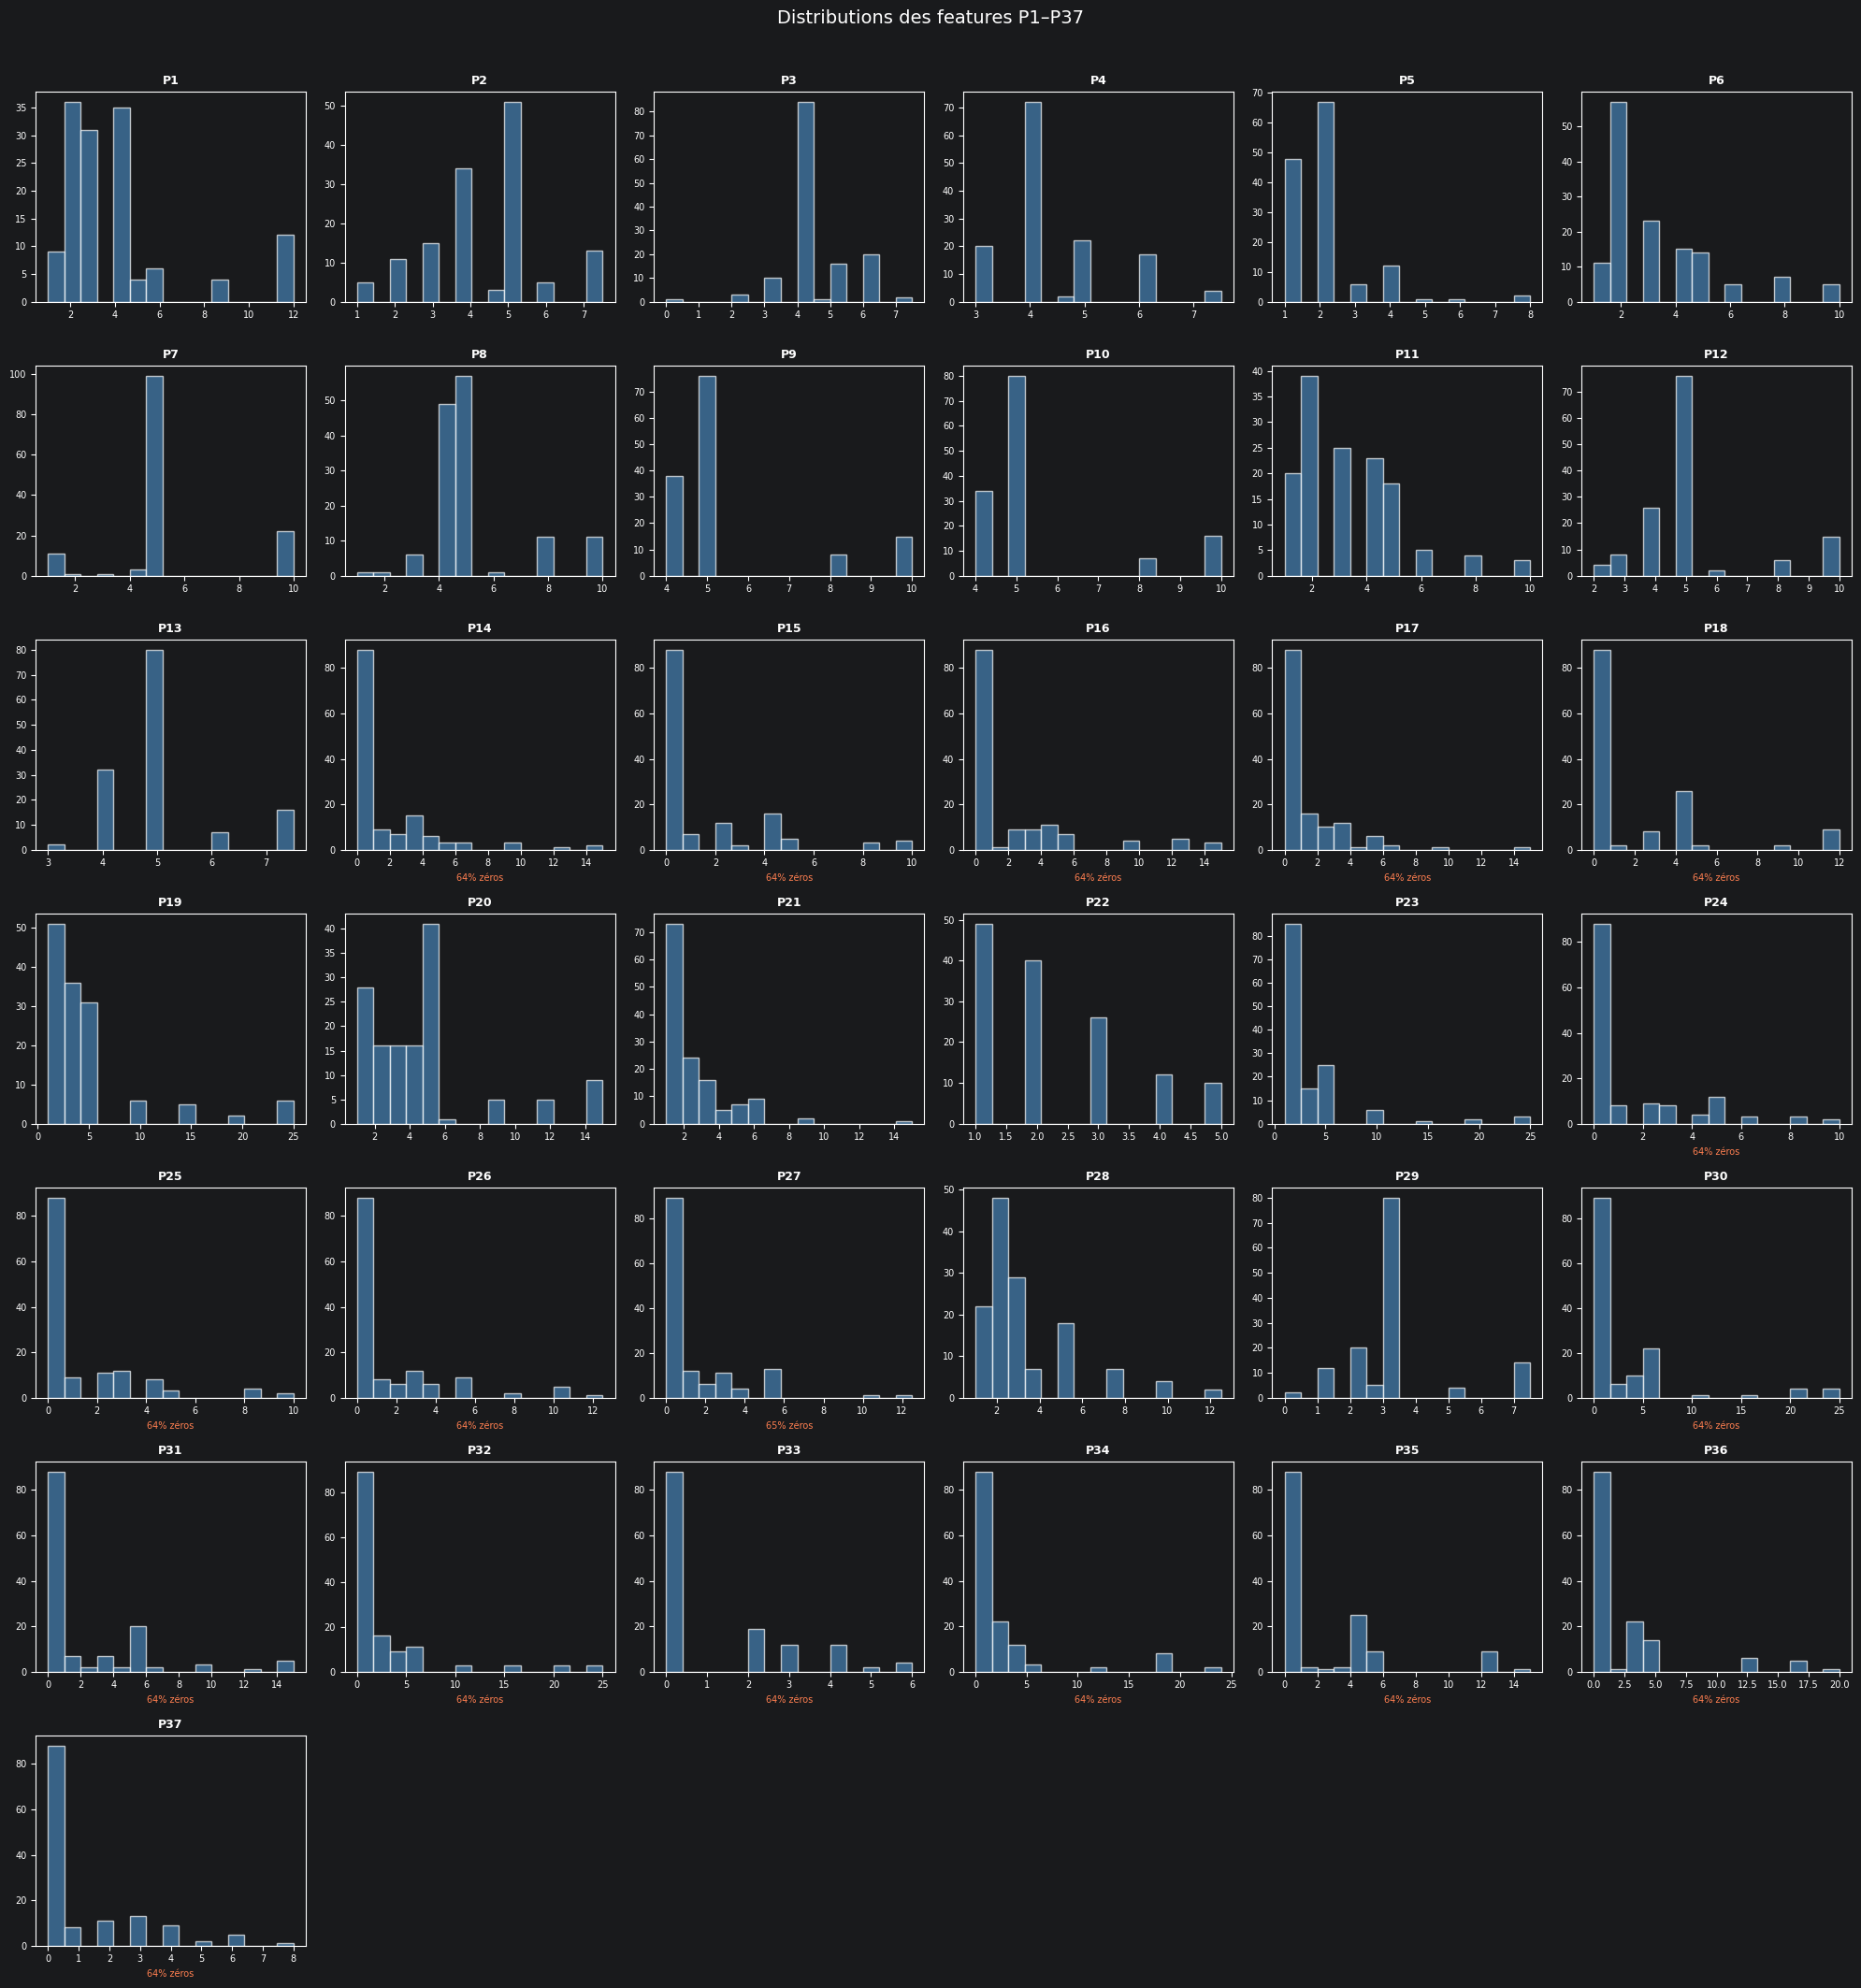

Features avec > 30% de zéros :
P27    0.649635
P37    0.642336
P25    0.642336
P26    0.642336
P18    0.642336
P17    0.642336
P16    0.642336
P15    0.642336
P14    0.642336
P24    0.642336
P30    0.642336
P31    0.642336
P32    0.642336
P33    0.642336
P34    0.642336
P35    0.642336
P36    0.642336


In [22]:
num_feats = [c for c in train.columns if c.startswith('P')]

n_cols = 6
n_rows = (len(num_feats) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_feats):
    axes[i].hist(train[col], bins=15, color='steelblue', edgecolor='white', alpha=0.7)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].tick_params(labelsize=7)
    pct_zero = (train[col] == 0).mean() * 100
    if pct_zero > 30:
        axes[i].set_xlabel(f'{pct_zero:.0f}% zéros', fontsize=7, color='coral')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions des features P1–P37', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

zero_pct = (train[num_feats] == 0).mean().sort_values(ascending=False)
print("Features avec > 30% de zéros :")
print(zero_pct[zero_pct > 0.3].to_string())

### Observations — Features P1–P37

#### Le constat frappant : 17 features sur 37 ont plus de 64% de zéros
Les features suivantes ont un taux de zéros ≥ 64% : **P14, P15, P16, P17, P18, P24, P25, P26, P27, P30, P31, P32, P33, P34, P35, P36, P37**.

Autrement dit, **pour plus de 2 restaurants sur 3, ces features valent 0**. Ce ne sont pas des features continues — ce sont plus probablement des **comptages conditionnels** (nombre de places de parking ? nombre d'aménagements spécifiques ?) qui ne s'appliquent qu'à certains types de sites.

#### Ce que ça implique
- Ces features à fort taux de zéros sont **très sparse** (éparses). La distribution "1 gros pic en 0 + quelques valeurs positives" est difficile à exploiter pour un modèle linéaire, mais les **arbres de décision** (Random Forest, XGBoost) gèrent très bien ce pattern via des splits `valeur == 0 / valeur > 0`.
- **Idée feature engineering** : créer des features binaires `P14_actif`, `P30_actif`, etc. (1 si valeur > 0, sinon 0) pour que le modèle linéaire puisse aussi exploiter ce signal.

#### Hétérogénéité des échelles
- Certaines features vont de 0 à 5 (P1, P2, P3...), d'autres de 0 à 25+ (P30, P31...).
- Un **StandardScaler** est indispensable pour les modèles linéaires. Les arbres (XGBoost, LightGBM) n'en ont pas besoin.

### 4.2 Scatter plots — Top 8 features vs `revenue`

Les distributions ci-dessus montrent comment chaque feature P est distribuée. Mais ce qui nous intéresse vraiment c'est : **est-ce que les features P ont une relation avec le revenue ?** Les scatter plots ci-dessous montrent chaque feature (axe X) contre le revenue (axe Y), avec la corrélation de Pearson (r) dans le titre.

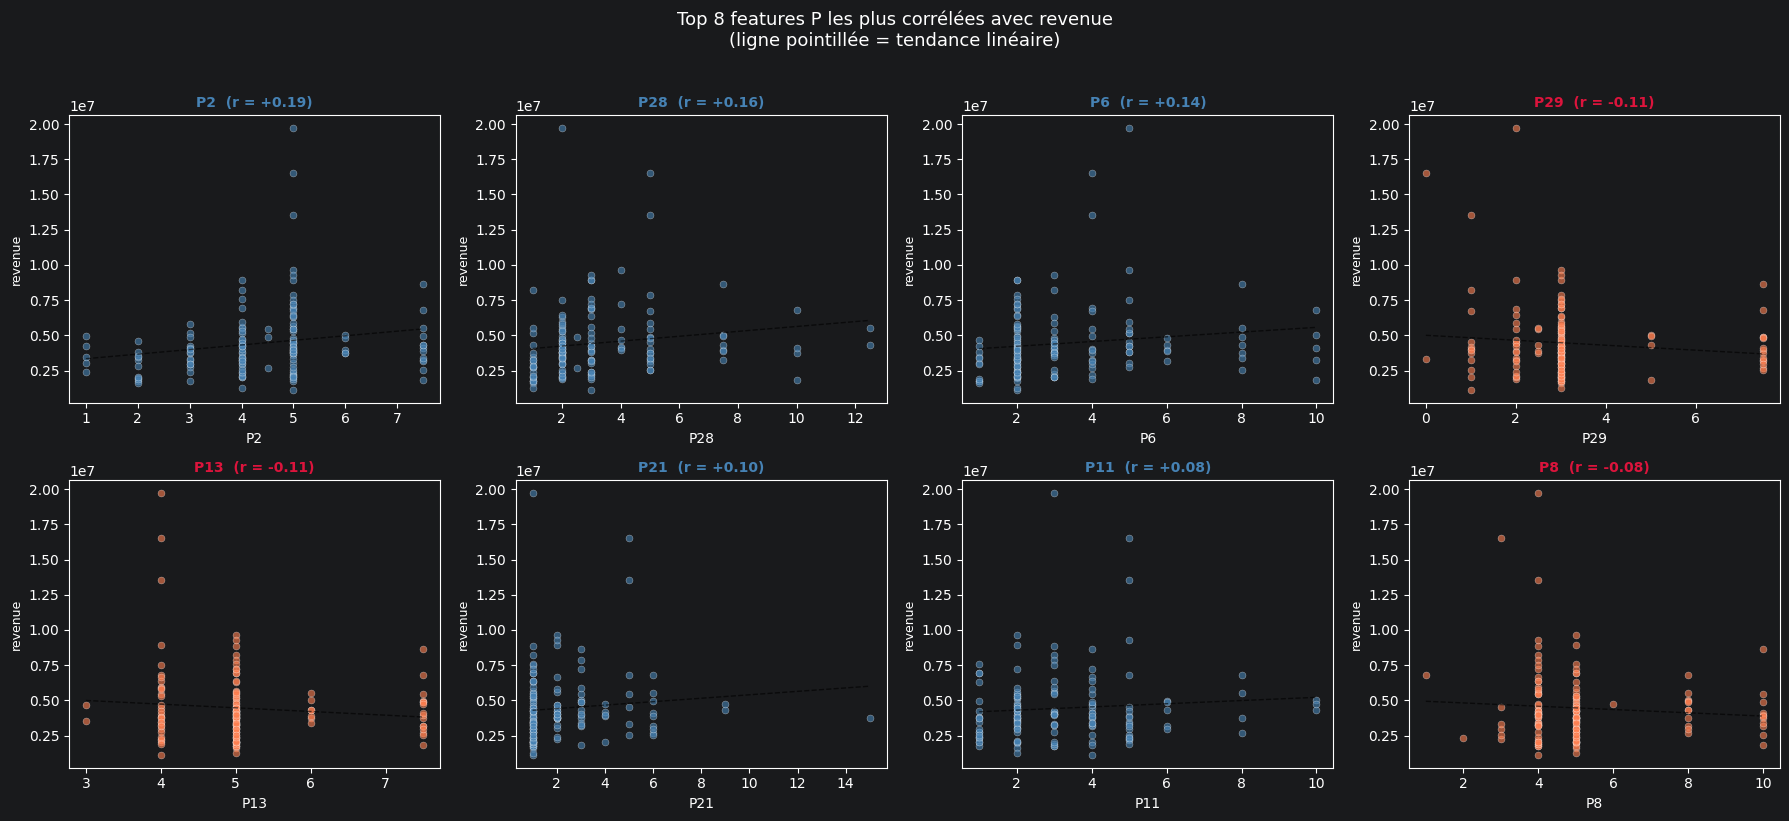

In [23]:
num_feats = [c for c in train.columns if c.startswith('P')]
corr_abs = (train[num_feats + ['revenue']]
            .corr()['revenue']
            .drop('revenue')
            .abs()
            .sort_values(ascending=False))
top8 = corr_abs.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top8):
    r = train[col].corr(train['revenue'])
    color = 'steelblue' if r >= 0 else 'coral'
    axes[i].scatter(train[col], train['revenue'], alpha=0.6, color=color, s=25, edgecolors='white', linewidth=0.3)
    z = np.polyfit(train[col].dropna(), train.loc[train[col].notna(), 'revenue'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(train[col].min(), train[col].max(), 100)
    axes[i].plot(x_line, p(x_line), 'k--', linewidth=1, alpha=0.6)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('revenue', fontsize=9)
    axes[i].set_title(f'{col}  (r = {r:+.2f})', fontsize=10, fontweight='bold',
                      color='steelblue' if r >= 0 else 'crimson')

plt.suptitle('Top 8 features P les plus corrélées avec revenue\n(ligne pointillée = tendance linéaire)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Corrélations features–revenue

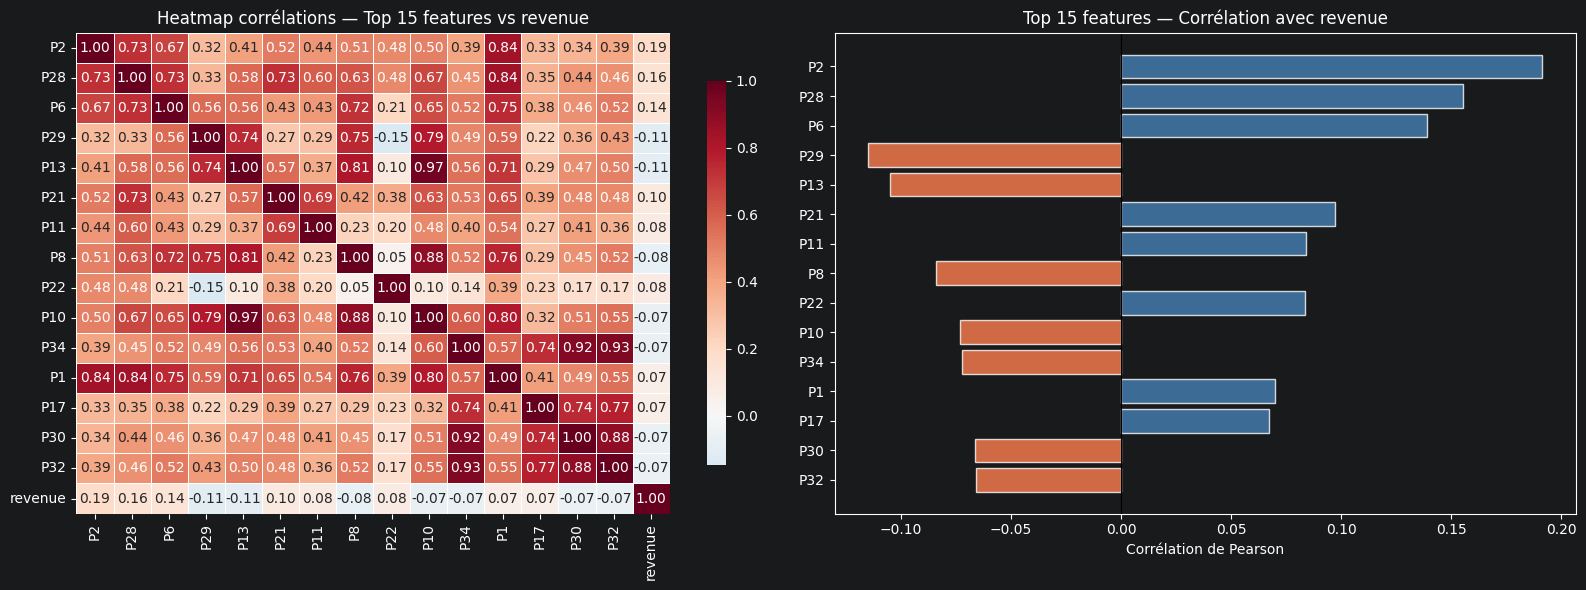

Top 10 features corrélées avec revenue :
P2     0.191518
P28    0.155534
P6     0.139094
P29   -0.114846
P13   -0.105085
P21    0.097411
P11    0.084247
P8    -0.084215
P22    0.083562
P10   -0.073220


In [24]:
num_feats = [c for c in train.columns if c.startswith('P')]
corr_with_rev = (
    train[num_feats + ['revenue']]
    .corr()['revenue']
    .drop('revenue')
    .sort_values(key=abs, ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_feats = corr_with_rev.head(15).index.tolist()
corr_matrix = train[top_feats + ['revenue']].corr()
sns.heatmap(corr_matrix, ax=axes[0], cmap='RdBu_r', center=0,
            annot=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title('Heatmap corrélations — Top 15 features vs revenue')

vals = corr_with_rev.head(15).values[::-1]
labels = corr_with_rev.head(15).index[::-1]
colors_bar = ['steelblue' if v >= 0 else 'coral' for v in vals]
axes[1].barh(labels, vals, color=colors_bar, alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 15 features — Corrélation avec revenue')
axes[1].set_xlabel('Corrélation de Pearson')

plt.tight_layout()
plt.show()

print("Top 10 features corrélées avec revenue :")
print(corr_with_rev.head(10).to_string())

### Observations — Corrélations

#### Le constat principal : les features P sont très faiblement corrélées avec revenue

| Rank | Feature | Corrélation |
|------|---------|-------------|
| 1 | P2 | +0.192 |
| 2 | P28 | +0.156 |
| 3 | P6 | +0.139 |
| 4 | P29 | -0.115 |
| 5 | P13 | -0.105 |
| ... | ... | ... |

**Aucune feature P ne dépasse une corrélation de 0.20 avec revenue.** C'est extrêmement faible — à titre de comparaison, `days_since_open` (calculé en Section 7) atteint **0.326**, soit presque le double de la meilleure feature P.

#### Lecture de la heatmap
- Bleu foncé = corrélation positive forte. Rouge foncé = corrélation négative forte. Blanc = pas de relation linéaire.
- Sur cette heatmap, tout est quasi-blanc → signal linéaire très faible dans les features P.

#### Ce que ça signifie pour la modélisation
- Les corrélations faibles ne signifient pas que les features P sont inutiles. Elles peuvent capturer des **relations non linéaires** ou des **interactions entre features** que la corrélation de Pearson ne détecte pas.
- Les **modèles à base d'arbres** (Random Forest, XGBoost, LightGBM) sont conçus pour exploiter ces signaux faibles en combinaison — c'est précisément pourquoi ils seront privilégiés ici.
- Pour les modèles linéaires : avec 37 features faiblement corrélées, la **régularisation L1 (Lasso)** permettra de sélectionner automatiquement les features utiles et d'annuler les autres.

## 6. Outliers

Borne inférieure IQR : -252,282
Borne supérieure IQR : 8,417,986
Outliers revenue     : 8 / 137 (5.8%)


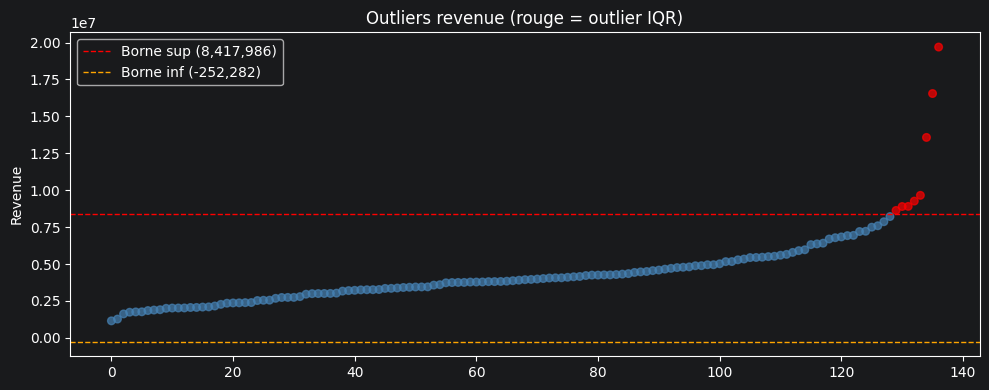


         City  City Group Type     revenue
16   İstanbul  Big Cities   FC  19696939.0
75   İstanbul  Big Cities   FC  16549064.0
99   İstanbul  Big Cities   IL  13575224.0
100  İstanbul  Big Cities   FC   9652350.0
133     İzmir  Big Cities   FC   9262754.0
24   İstanbul  Big Cities   IL   8904084.0
116     İzmir  Big Cities   FC   8894598.0
49   İstanbul  Big Cities   FC   8630682.0


In [25]:
q1 = train['revenue'].quantile(0.25)
q3 = train['revenue'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outliers = train[(train['revenue'] < lower) | (train['revenue'] > upper)]

print(f"Borne inférieure IQR : {lower:,.0f}")
print(f"Borne supérieure IQR : {upper:,.0f}")
print(f"Outliers revenue     : {len(outliers)} / {len(train)} ({len(outliers)/len(train)*100:.1f}%)")

sorted_rev = train['revenue'].sort_values().values
colors_out = ['red' if (v < lower or v > upper) else 'steelblue' for v in sorted_rev]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(train)), sorted_rev, c=colors_out, alpha=0.7, s=30)
ax.axhline(upper, color='red', linestyle='--', linewidth=1, label=f'Borne sup ({upper:,.0f})')
ax.axhline(lower, color='orange', linestyle='--', linewidth=1, label=f'Borne inf ({lower:,.0f})')
ax.set_title('Outliers revenue (rouge = outlier IQR)')
ax.set_ylabel('Revenue')
ax.legend()
plt.tight_layout()
plt.show()

if len(outliers) > 0:
    print()
    print(outliers[['City', 'City Group', 'Type', 'revenue']].sort_values('revenue', ascending=False).to_string())

### Observations — Outliers

#### Les chiffres réels
- **8 outliers** sur 137 observations (**5.8%** du dataset)
- Borne supérieure IQR : **8 417 986**

#### Profil des outliers — un pattern très clair

| City | City Group | Type | Revenue |
|------|------------|------|---------|
| İstanbul | Big Cities | FC | 19 696 939 |
| İstanbul | Big Cities | FC | 16 549 064 |
| İstanbul | Big Cities | IL | 13 575 224 |
| İstanbul | Big Cities | FC | 9 652 350 |
| İzmir | Big Cities | FC | 9 262 754 |
| İstanbul | Big Cities | IL | 8 904 084 |
| İzmir | Big Cities | FC | 8 894 598 |
| İstanbul | Big Cities | FC | 8 630 682 |

**100% des outliers sont en Big Cities** (Istanbul ou Izmir). 6 sur 8 sont à Istanbul. Aucun outlier dans "Other" — aucun restaurant en ville secondaire n'atteint les niveaux de revenu des sites premium d'Istanbul.

#### Faut-il les supprimer ?
- **Non** — ce ne sont pas des erreurs de mesure, ce sont de vrais restaurants très rentables qui existent dans la réalité.
- Avec 137 observations, supprimer 8 restaurants = perdre 5.8% du dataset, ce qui est inacceptable.
- La transformation `log(revenue)` atténue déjà l'impact de ces valeurs extrêmes sur le modèle.

## 7. Feature engineering exploratoire

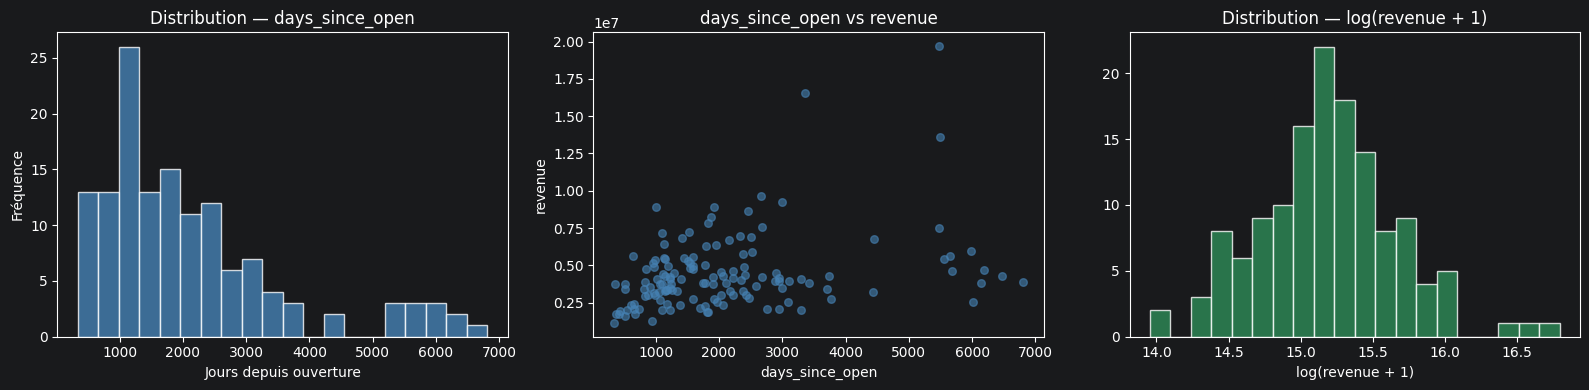

Corrélation days_since_open / revenue : 0.326
Skewness revenue      : 2.793
Skewness log_revenue  : 0.307


In [26]:
from datetime import datetime

ref_date = datetime(2015, 1, 1)

train_fe = train.copy()
train_fe['open_date_dt'] = pd.to_datetime(train_fe['Open Date'], format='%m/%d/%Y')
train_fe['days_since_open'] = (ref_date - train_fe['open_date_dt']).dt.days
train_fe['log_revenue'] = np.log1p(train_fe['revenue'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(train_fe['days_since_open'], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution — days_since_open')
axes[0].set_xlabel('Jours depuis ouverture')
axes[0].set_ylabel('Fréquence')

axes[1].scatter(train_fe['days_since_open'], train_fe['revenue'], alpha=0.6, color='steelblue', s=30)
axes[1].set_xlabel('days_since_open')
axes[1].set_ylabel('revenue')
axes[1].set_title('days_since_open vs revenue')

axes[2].hist(train_fe['log_revenue'], bins=20, color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('Distribution — log(revenue + 1)')
axes[2].set_xlabel('log(revenue + 1)')

plt.tight_layout()
plt.show()

corr_age = train_fe['days_since_open'].corr(train_fe['revenue'])
print(f"Corrélation days_since_open / revenue : {corr_age:.3f}")
print(f"Skewness revenue      : {train_fe['revenue'].skew():.3f}")
print(f"Skewness log_revenue  : {train_fe['log_revenue'].skew():.3f}")

### Observations — Feature engineering

#### `days_since_open` : la feature la plus corrélée avec revenue — de tout le dataset

> Corrélation `days_since_open` / revenue : **r = 0.326**

C'est la **corrélation la plus élevée** de toutes nos features — y compris les 37 features P anonymisées. La meilleure feature P (P2) n'atteint que r=0.192. En créant simplement `days_since_open` depuis `Open Date`, on a fabriqué la feature la plus prédictive du dataset.

**Interprétation** : les restaurants ouverts depuis longtemps tendent à avoir un revenu plus élevé. C'est cohérent : l'ancienneté reflète la maturité de la clientèle, la notoriété locale accumulée, et la capacité à survivre = être rentable.

#### Impact de la transformation log (rappel chiffré)
| | Skewness |
|---|---|
| `revenue` brut | **2.793** |
| `log(revenue + 1)` | **0.307** |

La skewness est divisée par ~9. Le modèle entraîné sur `log(revenue)` voit une cible presque gaussienne.

#### Plan d'encodage final
| Feature | Stratégie | Raison |
|---------|-----------|--------|
| `City Group` | One-hot (1 colonne) | 2 modalités, signal fort (médiane +13%) |
| `Type` | One-hot (2 colonnes) | 3 modalités — attention DT=1 seul obs |
| `City` | Supprimer | 34 modalités, trop risqué / 137 obs |
| `Open Date` | → `days_since_open` | Feature la plus corrélée (r=0.326) |
| `Id` | Supprimer | Aucun signal |

## 8. Conclusions & implications pour la modélisation

### Ce qu'on a appris sur les données

| Insight | Chiffre clé | Implication |
|---------|-------------|-------------|
| Dataset minuscule | 137 train / 100 000 test | KFold 5–10, pas de hold-out fixe |
| Revenue très skewed | Skewness 2.793 | Entraîner sur `log1p(revenue)`, sortie `expm1()` |
| Log-transform très efficace | Skewness → 0.307 | Décision validée par les données |
| Features P très faiblement corrélées | Max r = 0.19 (P2) | Signal linéaire quasi-absent dans les P |
| `days_since_open` feature la plus forte | **r = 0.326** | À inclure absolument — meilleure feature du dataset |
| 17 features P ont > 64% de zéros | P14–P18, P24–P27, P30–P37 | Créer des features binaires `Px_actif` |
| Outliers localisés | 8 outliers, tous Istanbul/Izmir | Ne pas supprimer — transformer avec log |
| Type DT = 1 seul restaurant | 1 obs sur 137 | Instabilité en cross-validation, à surveiller |
| City Group signal modéré | Médiane +13% Big Cities | À encoder, mais pas la feature dominante |

### Recommandations pour la modélisation

1. **Target** : `log1p(revenue)` — validé empiriquement (skewness 2.793 → 0.307)
2. **Features à inclure** : `days_since_open` (r=0.326), `City Group` (one-hot), `Type` (one-hot), toutes les features P
3. **Features à exclure** : `Id`, `City` (34 modalités / 137 obs), `Open Date` (remplacée par `days_since_open`)
4. **Feature engineering à tester** : colonnes binaires `Px_actif` pour les 17 features à fort taux de zéros
5. **Modèles prioritaires** : arbres d'abord (Random Forest, XGBoost, LightGBM) — ils gèrent les features sparse et les relations non linéaires que la corrélation n'a pas détectées
6. **Validation** : KFold 5 ou 10 folds — avec StratifiedKFold si possible pour garder la distribution de City Group dans chaque fold